In [76]:
!pip install medmnist

In [77]:
! pip install -q neptune

In [78]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
import neptune

import medmnist
from medmnist import INFO, Evaluator

In [79]:
NEPTUNE_PROJECT_NAME = "sigk/data-generation"
NEPTUNE_API_KEY = input("Enter Neptune API key: ")

Enter Neptune API key: eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJlZmIwZTU3OS0xZmJjLTRiZjEtODZmNS0yOGI2NjI1ZjE4NDgifQ==


In [80]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [81]:
# data_flag = 'bloodmnist'
data_flag = 'dermamnist'
# data_flag = 'pathmnist'
download = True

NUM_EPOCHS = 10
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [82]:
# # preprocessing
# data_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[.5], std=[.5])
# ])

# # load the data
# train_dataset = DataClass(split='train', transform=data_transform, download=download)
# test_dataset = DataClass(split='test', transform=data_transform, download=download)

# pil_dataset = DataClass(split='train', download=download)

# # encapsulate data into dataloader form
# train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
# test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)


In [83]:
# print(train_dataset)
# print("===================")
# print(test_dataset)

In [84]:
# visualization

# train_dataset.montage(length=1)

In [85]:
# montage

# train_dataset.montage(length=20)

In [86]:
# class MedModel(nn.Module):
#     def __init__(self, in_channels, num_classes):
#         super(MedModel, self).__init__()

#         # 1. Pobierz model z wagami ImageNet
#         self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
#         for param in self.model.parameters():
#           param.requires_grad = False

#         # 2. Zmniejsz kernel i stride w conv1 (dla małych obrazków)
#         # self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

#         # 3. Wywal maxpool, bo dla małych obrazów zjada za dużo informacji
#         # self.model.maxpool = nn.Identity()

#         # 4. Zamień ostatnią warstwę FC na własną
#         in_features = self.model.fc.in_features
#         self.model.fc = nn.Linear(in_features, num_classes)

#     def forward(self, x):
#         return self.model(x)

# model = MedModel(in_channels=n_channels, num_classes=n_classes)

# # define loss function and optimizer
# if task == "multi-label, binary-class":
#     criterion = nn.BCEWithLogitsLoss()
# else:
#     criterion = nn.CrossEntropyLoss()

# params_to_update = [p for p in model.parameters() if p.requires_grad]
# optimizer = optim.Adam(params_to_update, lr=lr)

In [87]:
# # train
# model = model.to(device)


# for epoch in range(NUM_EPOCHS):
#     train_correct = 0
#     train_total = 0
#     test_correct = 0
#     test_total = 0

#     model.train()
#     for inputs, targets in tqdm(train_loader):
#         inputs = inputs.to(device)
#         targets = targets.to(device)
#         # forward + backward + optimize
#         optimizer.zero_grad()
#         outputs = model(inputs)

#         if task == 'multi-label, binary-class':
#             targets = targets.to(torch.float32)
#             loss = criterion(outputs, targets)
#         else:
#             targets = targets.squeeze().long()
#             loss = criterion(outputs, targets)

#         loss.backward()
#         optimizer.step()

In [88]:
# # evaluation

# def test(split):
#     model.eval()
#     y_true = torch.tensor([])
#     y_score = torch.tensor([])
#     y_true = y_true.to(device)
#     y_score = y_score.to(device)

#     data_loader = train_loader_at_eval if split == 'train' else test_loader

#     with torch.no_grad():
#         for inputs, targets in data_loader:
#             inputs = inputs.to(device)
#             targets = targets.to(device)
#             outputs = model(inputs)

#             if task == 'multi-label, binary-class':
#                 targets = targets.to(torch.float32)
#                 outputs = outputs.softmax(dim=-1)
#             else:
#                 targets = targets.squeeze().long()
#                 outputs = outputs.softmax(dim=-1)
#                 targets = targets.float().resize_(len(targets), 1)

#             y_true = torch.cat((y_true, targets), 0)
#             y_score = torch.cat((y_score, outputs), 0)

#         y_true = y_true.cpu().numpy()
#         y_score = y_score.detach().cpu().numpy()

#         evaluator = Evaluator(data_flag, split)
#         metrics = evaluator.evaluate(y_score)

#         print('%s  auc: %.3f  acc:%.3f' % (split, *metrics))


# print('==> Evaluating ...')
# test('train')
# test('test')

In [89]:
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

100%|██████████| 19.7M/19.7M [00:02<00:00, 9.52MB/s]


In [90]:
train_dataset.montage(length=1)

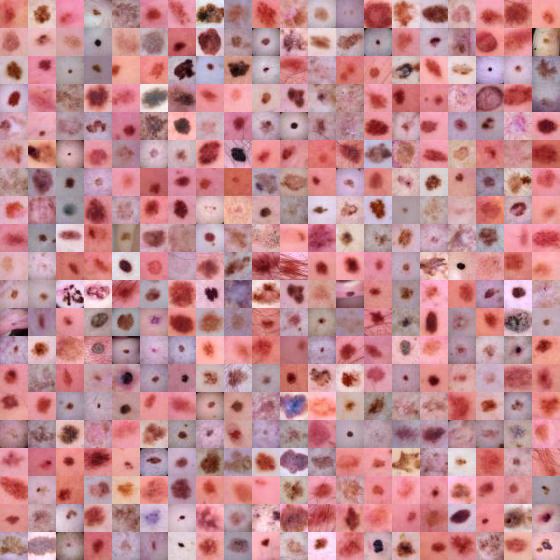

In [91]:
train_dataset.montage(length=20)

In [92]:
class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = 100,
        output_channels: int = 3,
        output_size: int = 64
    ):
        super().__init__()
        assert output_size % 16 == 0, "Output size must be divisible by 16 (e.g., 64, 128)"

        self.latent_dim = latent_dim
        self.output_size = output_size
        self.output_channels = output_channels
        self.init_size = output_size // 16  # Initial feature map size (e.g., 4x4 if 64x64 output)

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * self.init_size * self.init_size),
            nn.ReLU(True)
        )

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),  # 4 -> 8
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 8 -> 16
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 16 -> 32
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 32 -> 64
            nn.Conv2d(32, output_channels, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()  # or Tanh if your data is scaled to [-1, 1]
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        out = self.fc(z)
        out = out.view(z.size(0), 256, self.init_size, self.init_size)
        img = self.upsample(out)
        return img

In [93]:
model = Generator(latent_dim=100, output_channels=3, output_size=64)

for images, labels in train_loader:
    print("Images shape (real):", images.shape)  # np. [128, 3, 64, 64] po preprocessing

    batch_size = images.size(0)
    latent_dim = 100
    z = torch.randn(batch_size, latent_dim)  # [128, 100]

    output = model(z)  # [128, 3, 64, 64]
    print("Generated image shape:", output.shape)
    break

Images shape (real): torch.Size([128, 3, 64, 64])
Generated image shape: torch.Size([128, 3, 64, 64])


In [94]:
class Discriminator(nn.Module):
    def __init__(
        self,
        input_channels: int = 3,
        input_size: int = 64
    ):
        super().__init__()
        assert input_size % 16 == 0, "Input size must be divisible by 16 (e.g., 64, 128)"

        self.input_channels = input_channels
        self.input_size = input_size
        self.final_size = input_size // 16  # Zakładamy 4 kroki downsamplingu: 64 → 32 → 16 → 8 → 4

        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=4, stride=2, padding=1),  # 64x64 → 32x32
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 32x32 → 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 16x16 → 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 8x8 → 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * self.final_size * self.final_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        out = self.classifier(x)
        return out

In [95]:
import torch
import torchvision

def train_gan(
    generator: nn.Module,
    discriminator: nn.Module,
    optimizer_G: optim.Optimizer,
    optimizer_D: optim.Optimizer,
    adversarial_loss: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 20,
    latent_dim: int = 100,
    lambda_l1: float = 100.0,
    run: 'neptune.Run' = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    l1_loss = nn.L1Loss()

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()
        total_g_loss = 0.0
        total_d_loss = 0.0

        for real_images, _ in train_loader:  # etykiety niepotrzebne
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # === Etap 1: TRENUJEMY DYSKRYMINATORA ===
            optimizer_D.zero_grad()

            # Dane rzeczywiste
            real_labels = torch.full((batch_size, 1), 0.9, device=device)  # label smoothing
            real_preds = discriminator(real_images)
            real_loss = adversarial_loss(real_preds, real_labels)

            # Dane sztuczne
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()  # odłączone od gradientów Generatora
            fake_labels = torch.zeros((batch_size, 1), device=device)
            fake_preds = discriminator(fake_images)
            fake_loss = adversarial_loss(fake_preds, fake_labels)

            # Całkowita strata dyskryminatora
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # === Etap 2: TRENUJEMY GENERATOR ===
            optimizer_G.zero_grad()

            z = torch.randn(batch_size, latent_dim, device=device)
            generated_images = generator(z)
            preds = discriminator(generated_images)

            g_loss_adv = adversarial_loss(preds, real_labels)  # generator chce oszukać dyskryminator
            g_loss_l1 = l1_loss(generated_images, real_images)
            g_loss = g_loss_adv + lambda_l1 * g_loss_l1
            g_loss.backward()
            optimizer_G.step()

            # === Logging ===
            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()

            if run:
                run["train/step/g_loss"].append(g_loss.item())
                run["train/step/d_loss"].append(d_loss.item())

        avg_g_loss = total_g_loss / len(train_loader)
        avg_d_loss = total_d_loss / len(train_loader)
        print(f"[Epoch {epoch+1}] G Loss: {avg_g_loss:.4f} | D Loss: {avg_d_loss:.4f}")

        if run:
            run["train/epoch/g_loss"].append(avg_g_loss)
            run["train/epoch/d_loss"].append(avg_d_loss)

            # Przykładowe wygenerowane obrazki - korzystamy z funkcji plot_predictions
            generator.eval()
            with torch.no_grad():
              z = torch.randn(16, latent_dim, device=device)
              fig = plot_predictions_gan(generator, val_loader=val_loader, n=4, latent_dim=latent_dim, device=device, show=False)
              run[f"train/epoch/{epoch+1}_samples"].upload(neptune.types.File.as_image(fig))


In [96]:
import matplotlib.pyplot as plt
import torch

def plot_predictions_gan(
    model: torch.nn.Module,
    val_loader: torch.utils.data.DataLoader,
    n: int = 5,
    latent_dim: int = 100,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    show: bool = True
) -> plt.Figure:
    model.eval()  # Ustaw model w tryb ewaluacji
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))  # Dwa wiersze dla Ground Truth i Prediction

    with torch.no_grad():
        for i, (real_images, _) in enumerate(val_loader):
            if i >= n:
                break

            real_images = real_images.to(device)

            # Generowanie obrazków z szumu
            z = torch.randn(real_images.size(0), latent_dim, device=device)  # Generujemy z losowego szumu
            generated_images = model(z)

            # Pierwszy wiersz: prawdziwe obrazy (Ground Truth)
            ax_gt = axes[0, i]
            ax_gt.imshow(real_images[i].cpu().permute(1, 2, 0).numpy())  # Prawdziwy obraz
            ax_gt.set_title(f"Real {i+1}")

            # Drugi wiersz: wygenerowane obrazy
            ax_pred = axes[1, i]
            ax_pred.imshow(generated_images[i].cpu().permute(1, 2, 0).numpy())  # Wygenerowany obraz
            ax_pred.set_title(f"Generated {i+1}")

        # Układ etykiet
        axes[0, 0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Generated', fontsize=12, fontweight='bold')

        for ax in axes.flat:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(pad=0.5)
    if show:
        plt.show()

    plt.close()
    return fig


In [97]:
# device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# G = Generator()
# D = Discriminator()
# G = G.to(device)
# D = D.to(device)

# lr_G = 1e-4
# lr_D = 1e-5
# optimizer_G = optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
# optimizer_D = optim.Adam(D.parameters(), lr=lr_G, betas=(0.5, 0.999))
# epochs=200
# lambda_l1=100

# adversarial_loss = nn.MSELoss()
# # adversarial_loss = nn.BCEWithLogitsLoss()

In [98]:
# run = neptune.init_run(
#     project=NEPTUNE_PROJECT_NAME,
#     api_token=NEPTUNE_API_KEY,
# )
# params = {
#     "generator_name": G.__class__.__name__,
#     "discriminator_name": D.__class__.__name__,
#     "generator_optimizer_name": optimizer_G.__class__.__name__,
#     "discriminator_optimizer_name": optimizer_D.__class__.__name__,
#     "generator_learning_rate": lr_G,
#     "discriminator_learning_rate": lr_D,
#     "adversarial_loss": adversarial_loss.__class__.__name__,
#     "lambda_l1": lambda_l1,
#     "epochs": epochs,
#     "dataset_size": len(train_dataset),
#     "dataset_version": data_flag,
#     "batch_size": batch_size,
# }
# run["parameters"] = params

In [99]:
# run.stop()

In [100]:
import os
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image

In [101]:
# start_time = datetime.now()
# train_gan(
#     G,
#     D,
#     optimizer_G,
#     optimizer_D,
#     adversarial_loss=adversarial_loss,
#     train_loader=train_loader,
#     val_loader=train_loader_at_eval,
#     lambda_l1=lambda_l1,
#     num_epochs=epochs,
#     run=run,
# )
# train_time = datetime.now() - start_time
# print(f"Training time: {train_time}")
# run["train/time"] = train_time.seconds

In [102]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=64, input_channels=3, input_size=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_size = input_size
        self.final_size = input_size // 8  # 64 → 32 → 16 → 8

        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 64, 4, stride=2, padding=1),   # 64 → 32
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),              # 32 → 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),             # 16 → 8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        flat_dim = 256 * self.final_size * self.final_size
        self.fc_mu = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(128, latent_dim),
        )
        self.fc_logvar = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.conv(x)
        x = x.view(batch_size, -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


In [103]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=64, output_channels=3, output_size=64):
        super().__init__()
        assert output_size % 8 == 0
        self.init_size = output_size // 8  # 8

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256 * self.init_size * self.init_size),
            nn.LeakyReLU(0.2),
        )

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),  # 8 → 16
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),  # 16 → 32
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),  # 32 → 64
            nn.Conv2d(64, output_channels, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        out = self.fc(z)
        out = out.view(z.size(0), 256, self.init_size, self.init_size)
        img = self.upsample(out)
        return img


In [104]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(input_channels, 32, 4, stride=2, padding=1),  # 64 → 32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 32 → 16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(64, 1, 4, stride=2, padding=0),  # 16 → 7
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)


In [105]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


In [106]:
def vae_loss(recon_x, x, mu, logvar):
    # Rekonstrukcja (np. BCE)
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    # KL Divergencja
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld, recon_loss, kld


In [107]:
!pip install pytorch-msssim

In [108]:
from pytorch_msssim import ssim
import torch.nn.functional as F

def vae_loss_with_ssim(recon_x, x, mu, logvar, alpha=0.5):
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
    ssim_loss = 1 - ssim(recon_x, x, data_range=1.0, size_average=False).sum()
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * bce + (1 - alpha) * ssim_loss + kld, bce, ssim_loss, kld


In [109]:
import torchvision.models as models
from torchvision import transforms

class VGGPerceptualLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True).features[:16].eval()  # warstwy do relu3_3
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, x, y):
        return F.mse_loss(self.vgg(x), self.vgg(y))

In [110]:
from pytorch_msssim import ssim
import torch.nn.functional as F

def recon_loss_ssim(x, recon, alpha=0.5, ssim_weight=0.5):
    """
    alpha: waga MSE vs SSIM
    ssim_weight: udział SSIM w całkowitej stracie perceptualnej (jeśli chcesz zmieniać)
    """
    mse = F.mse_loss(recon, x, reduction='sum')
    ssim_loss = 1 - ssim(recon, x, data_range=2.0, size_average=False).sum()

    # Połączone: MSE + SSIM
    perceptual_part = ssim_weight * ssim_loss
    recon_total = alpha * mse + (1 - alpha) * perceptual_part
    return recon_total


In [111]:
import torch.nn.functional as F

def vae_gan_loss(
    recon_x, x, mu, logvar, d_real, d_fake,
    beta=1.0, gamma=2.0
):
    # Rekonstrukcja: BCE
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KLD
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # GAN loss (dla generatora)
    valid = torch.ones_like(d_fake)
    gan_loss = F.binary_cross_entropy(d_fake, valid)

    # total = recon_loss + beta * kld
    total = recon_loss + gamma * gan_loss + beta * kld
    return total, recon_loss, gan_loss, kld


In [112]:
import torch
import torch.nn.functional as F

def train_vae_gan(
    encoder,
    decoder,
    discriminator,
    optimizer_vae,
    optimizer_d,
    train_loader,
    val_loader,
    num_epochs=20,
    pretrain_epochs=20,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    run=None,
    latent_dim=256,
):
    encoder.to(device)
    decoder.to(device)
    discriminator.to(device)

    for epoch in range(num_epochs):
        encoder.train()
        decoder.train()
        discriminator.train()

        total_vae_loss = 0.0
        total_recon = 0.0
        total_kld = 0.0
        total_gan = 0.0
        total_d = 0.0
        total_samples = 0

        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            batch_size = imgs.size(0)
            total_samples += batch_size

            mu, logvar = encoder(imgs)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            if epoch >= pretrain_epochs:
                # === Train Discriminator ===
                real_pred = discriminator(imgs.detach())
                fake_pred_d = discriminator(recon.detach())

                valid = torch.full_like(real_pred, 0.8)
                fake = torch.full_like(fake_pred_d, 0.2)

                d_loss_real = F.binary_cross_entropy(real_pred, valid, reduction='sum')
                d_loss_fake = F.binary_cross_entropy(fake_pred_d, fake, reduction='sum')
                d_loss = (d_loss_real + d_loss_fake) / 2

                optimizer_d.zero_grad()
                d_loss.backward()
                optimizer_d.step()

                # === Train VAE + GAN ===
                fake_pred_g = discriminator(recon)
                vae_loss, recon_loss, gan_loss, kld = vae_gan_loss(
                    recon_x=recon,
                    x=imgs,
                    mu=mu,
                    logvar=logvar,
                    d_real=real_pred,
                    d_fake=fake_pred_g,
                    beta=1.0,
                    gamma=4.0
                )
            else:
                d_loss = torch.tensor(0.0, device=device)
                gan_loss = torch.tensor(0.0, device=device)
                recon_loss = F.binary_cross_entropy(recon, imgs, reduction='sum')
                kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                vae_loss = recon_loss + kld

            optimizer_vae.zero_grad()
            vae_loss.backward()
            optimizer_vae.step()

            # Suma wartości (dzielona potem przez total_samples)
            total_vae_loss += vae_loss.item()
            total_recon += recon_loss.item()
            total_gan += gan_loss.item()
            total_kld += kld.item()
            total_d += d_loss.item()

        # Średnie per próbka
        log_vals = {
            "loss": total_vae_loss / total_samples,
            "recon": total_recon / total_samples,
            "gan": total_gan / total_samples,
            "kld": total_kld / total_samples,
            "d_loss": total_d / total_samples,
        }

        print(f"Epoch {epoch+1}: " + " | ".join([f"{k.upper()} {v:.4f}" for k, v in log_vals.items()]))

        if run:
            for key, val in log_vals.items():
                run[f"train/epoch/{key}"].append(val)

            # Log samples
            encoder.eval()
            decoder.eval()
            with torch.no_grad():
                fig = plot_predictions_vae(
                    encoder=encoder,
                    decoder=decoder,
                    val_loader=val_loader,
                    n=4,
                    latent_dim=latent_dim,
                    device=device,
                    show=False
                )
                run[f"train/epoch/{epoch+1}_samples"].upload(
                    neptune.types.File.as_image(fig)
                )
            encoder.train()
            decoder.train()


In [113]:
import matplotlib.pyplot as plt
import torch

def plot_predictions_vae(
    encoder: torch.nn.Module,
    decoder: torch.nn.Module,
    val_loader: torch.utils.data.DataLoader,
    n: int = 5,
    latent_dim: int = 100,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    show: bool = True
) -> plt.Figure:
    encoder.eval()
    decoder.eval()

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))

    with torch.no_grad():
        for i, (real_images, _) in enumerate(val_loader):
            if i >= n:
                break

            real_images = real_images.to(device)
            x = real_images[0].unsqueeze(0)

            mu, logvar = encoder(x)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            # Ground Truth
            ax_gt = axes[0, i]
            img_gt = x[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
            ax_gt.imshow(img_gt)
            ax_gt.set_title(f"Real {i+1}")

            # Reconstruction
            ax_recon = axes[1, i]
            img_recon = recon[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
            ax_recon.imshow(img_recon)
            ax_recon.set_title(f"Recon {i+1}")

        axes[0, 0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Reconstruction', fontsize=12, fontweight='bold')

        for ax in axes.flat:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(pad=0.5)
    if show:
        plt.show()

    plt.close()
    return fig


In [114]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 64

encoder = Encoder(latent_dim=latent_dim, input_channels=3, input_size=64).to(device)
decoder = Decoder(latent_dim=latent_dim, output_channels=3, output_size=64).to(device)
discriminator = Discriminator(input_channels=3).to(device)

lr = 1e-3
optimizer_vae = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=1e-4)
epochs = 200


In [115]:
run = neptune.init_run(
    project=NEPTUNE_PROJECT_NAME,
    api_token=NEPTUNE_API_KEY,
)
params = {
    "encoder_name": encoder.__class__.__name__,
    "decoder_name": decoder.__class__.__name__,
    "optimizer_vae_name": optimizer_vae.__class__.__name__,
    "optimizer_d_name": optimizer_d.__class__.__name__,
    "learning_rate": lr,
    "epochs": epochs,
    "dataset_size": len(train_dataset),
    "dataset_version": data_flag,
    "batch_size": batch_size,
}
run["parameters"] = params

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/data-generation/e/DAT-36


In [116]:
from datetime import datetime

start_time = datetime.now()

train_vae_gan(
    encoder=encoder,
    decoder=decoder,
    discriminator=discriminator,
    optimizer_vae=optimizer_vae,
    optimizer_d=optimizer_d,
    train_loader=train_loader,
    val_loader=train_loader_at_eval,
    num_epochs=epochs,
    device=device,
    run=run,
    latent_dim=latent_dim
)

train_time = datetime.now() - start_time
print(f"Training time: {train_time}")
run["train/time"] = train_time.seconds


Epoch 1: LOSS 7647.2397 | RECON 7544.1863 | GAN 0.0000 | KLD 103.0533 | D_LOSS 0.0000
Epoch 2: LOSS 7394.1803 | RECON 7348.0340 | GAN 0.0000 | KLD 46.1463 | D_LOSS 0.0000
Epoch 3: LOSS 7373.4020 | RECON 7332.0278 | GAN 0.0000 | KLD 41.3742 | D_LOSS 0.0000
Epoch 4: LOSS 7365.6019 | RECON 7325.7751 | GAN 0.0000 | KLD 39.8268 | D_LOSS 0.0000
Epoch 5: LOSS 7355.7601 | RECON 7317.7848 | GAN 0.0000 | KLD 37.9753 | D_LOSS 0.0000
Epoch 6: LOSS 7349.5841 | RECON 7313.2496 | GAN 0.0000 | KLD 36.3346 | D_LOSS 0.0000
Epoch 7: LOSS 7345.6698 | RECON 7310.4903 | GAN 0.0000 | KLD 35.1795 | D_LOSS 0.0000
Epoch 8: LOSS 7340.2838 | RECON 7306.8507 | GAN 0.0000 | KLD 33.4332 | D_LOSS 0.0000
Epoch 9: LOSS 7336.7888 | RECON 7304.1894 | GAN 0.0000 | KLD 32.5994 | D_LOSS 0.0000
Epoch 10: LOSS 7335.4505 | RECON 7303.2671 | GAN 0.0000 | KLD 32.1834 | D_LOSS 0.0000
Epoch 11: LOSS 7330.4281 | RECON 7299.5513 | GAN 0.0000 | KLD 30.8769 | D_LOSS 0.0000
Epoch 12: LOSS 7328.8011 | RECON 7298.1047 | GAN 0.0000 | KLD 

In [117]:
run.stop()

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 7 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 7 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/sigk/data-generation/e/DAT-36/metadata


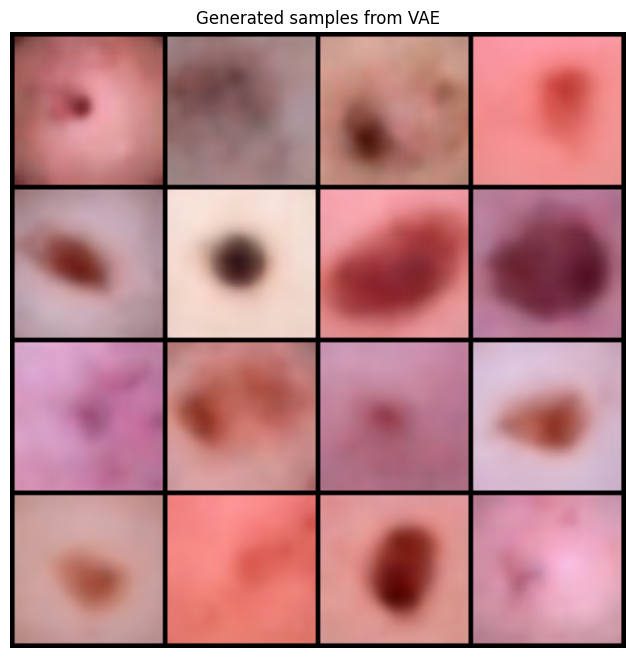

In [118]:
import matplotlib.pyplot as plt
import torchvision

decoder.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)  # latent_dim taki sam jak w trenowaniu
    samples = decoder(z)  # [16, 3, 64, 64]

    # Tworzymy grid 4x4 z normalizacją do [0,1]
    grid_img = torchvision.utils.make_grid(samples, nrow=4, normalize=True)

    # Wyświetlamy obrazek
    plt.figure(figsize=(8,8))
    plt.imshow(grid_img.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Generated samples from VAE')
    plt.show()
